In [1]:
import pandas as pd

train_final = pd.read_csv("../data/processed_train.csv")
test_final = pd.read_csv("../data/processed_test.csv")

print("Train shape:", train_final.shape)
print("Test shape:", test_final.shape)
train_final.head()

Train shape: (125973, 123)
Test shape: (22544, 123)


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH,binary_label
0,-0.110249,-0.007679,-0.004919,-0.014089,-0.089486,-0.007736,-0.095076,-0.027023,-0.809262,-0.011664,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,normal
1,-0.110249,-0.007737,-0.004919,-0.014089,-0.089486,-0.007736,-0.095076,-0.027023,-0.809262,-0.011664,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,normal
2,-0.110249,-0.007762,-0.004919,-0.014089,-0.089486,-0.007736,-0.095076,-0.027023,-0.809262,-0.011664,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,attack
3,-0.110249,-0.007723,-0.002891,-0.014089,-0.089486,-0.007736,-0.095076,-0.027023,1.235694,-0.011664,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,normal
4,-0.110249,-0.007728,-0.004814,-0.014089,-0.089486,-0.007736,-0.095076,-0.027023,1.235694,-0.011664,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,normal


Loading all processed data


In [2]:
X_train = train_final.drop(columns=["binary_label"])
y_train = train_final["binary_label"]

X_test = test_final.drop(columns=["binary_label"])
y_test = test_final["binary_label"]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (125973, 122)
y_train shape: (125973,)


Training Logistic Regression 

In [3]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

print("Model trained.")

Model trained.


In [4]:
y_pred = log_reg.predict(X_test)

print(y_pred[:10])

['attack' 'attack' 'normal' 'attack' 'normal' 'normal' 'normal' 'normal'
 'normal' 'normal']


.predict(X_test) — feeds all 22,544 test rows through the trained model, and gets back its guess (normal or attack) for each one. Critically, the model has never seen these exact rows during training — this is the real test of whether it learned a genuine pattern.
y_pred[:10] — just peeking at the first 10 predictions, so you can see what the output actually looks like (an array of normal/attack strings, one per row)

In [5]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

      attack       0.92      0.62      0.74     12833
      normal       0.65      0.93      0.76      9711

    accuracy                           0.75     22544
   macro avg       0.78      0.77      0.75     22544
weighted avg       0.80      0.75      0.75     22544



classification_report — a scikit-learn function that calculates precision, recall, and one more metric (F1-score, which we haven't covered yet — I'll explain it once you see it in the output, using your real numbers) for each class separately (attack and normal), plus overall accuracy
y_test — the true, correct answers
y_pred — what your model predicted (from the last cell)
The function compares these two side by side and works out all the TP/TN/FP/FN counts internally, then reports the resulting metrics

In [6]:
cm = confusion_matrix(y_test, y_pred, labels=["normal", "attack"])
print(cm)


[[8993  718]
 [4831 8002]]


confusion_matrix(y_test, y_pred, ...) — compares your true answers against your model's predictions, and tallies up every combination into a small grid
labels=["normal", "attack"] — we're explicitly telling it the order we want the rows/columns in, so the output is predictable and easy to read (rather than whatever alphabetical/internal order it might default to

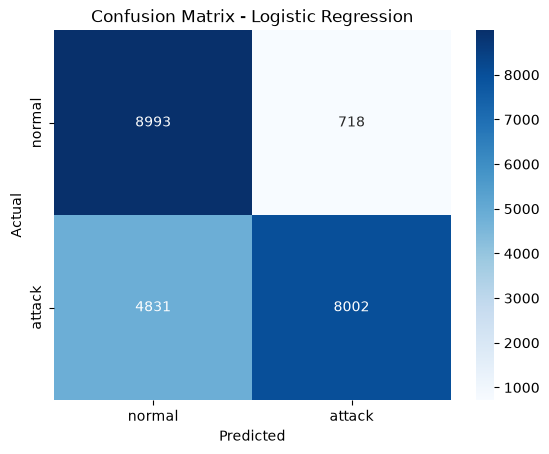

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

os.makedirs("../images", exist_ok=True)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["normal", "attack"], yticklabels=["normal", "attack"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.savefig("../images/confusion_matrix_logreg.png", dpi=150, bbox_inches="tight")
plt.show()

os.makedirs("../images", exist_ok=True) — creates a new images folder at your project root (sibling to data and notebooks) if it doesn't already exist. exist_ok=True just means "don't error if it's already there."
plt.savefig(...) — saves the actual plot image as a PNG file. dpi=150 controls image sharpness, bbox_inches="tight" trims excess whitespace around the plot. This line must come before plt.show(), since plt.show() can clear the plot from memory afterward.

Decission Tree Model

In [9]:
from sklearn.tree import DecisionTreeClassifier

dec_tree = DecisionTreeClassifier(random_state=42)
dec_tree.fit(X_train, y_train)

print("Model trained.")

Model trained.


DecisionTreeClassifier(random_state=42) — creates the model. random_state=42 is worth explaining: Decision Trees have some randomness in how they choose between equally-good splits, so fixing random_state to a specific number makes your results reproducible — if you (or anyone else) reruns this exact code, you'll get the exact same tree, not a slightly different one each time. 42 is just a number people commonly use as a convention (a nod to "Hitchhiker's Guide to the Galaxy," genuinely no deeper meaning) — any fixed number works the same way.
dec_tree — new variable name, distinct from log_reg, so both trained models stay available in memory at once
.fit(X_train, y_train) — same training step as before, same data, different model type

In [10]:
y_pred_tree = dec_tree.predict(X_test)

print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

      attack       0.96      0.65      0.77     12833
      normal       0.68      0.97      0.80      9711

    accuracy                           0.79     22544
   macro avg       0.82      0.81      0.79     22544
weighted avg       0.84      0.79      0.78     22544



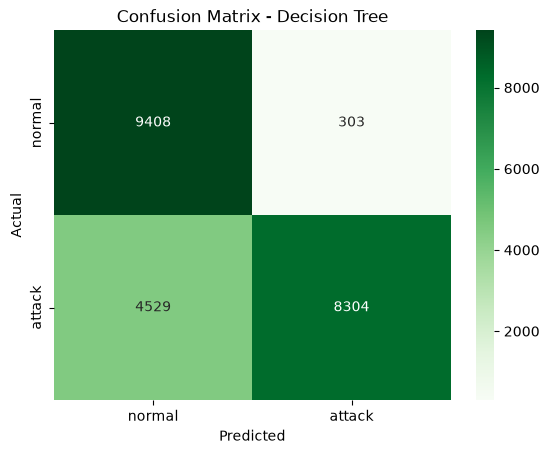

[[9408  303]
 [4529 8304]]


In [11]:
cm_tree = confusion_matrix(y_test, y_pred_tree, labels=["normal", "attack"])

sns.heatmap(cm_tree, annot=True, fmt="d", cmap="Greens", xticklabels=["normal", "attack"], yticklabels=["normal", "attack"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")
plt.savefig("../images/confusion_matrix_tree.png", dpi=150, bbox_inches="tight")
plt.show()

print(cm_tree)